# Linear-equivalent disc / annulus with cone linearization

Python version of `linConeMain.m` + `analyzeLinearDiscCone.m` + `populationLinConeDisc.m`
(linCone repo). Same structure as the other single-cell notebooks — discover, group, analyze,
store, population figure — and sharing their light-level helpers.

**The experiment.** Every natural-image patch is shown three ways, interleaved:

| `stimulusTag` | what it is |
|---|---|
| `image` | the image patch itself |
| `intensity` | uniform disc at the linear-equivalent intensity (patch averaged over the RF) |
| `linConeIntensity` / `lin cone intensity` | uniform disc at the **cone-linearized** equivalent intensity — averaged after a Weber cone nonlinearity `I / (I + WeberConstant)` |

Comparing image against each disc asks how much of the cell's preference for the real image
survives when the averaging happens in cone-response space instead of intensity space. The
measure is the nonlinearity index per patch, exactly as `computeNLI` defines it:

$$\mathrm{NLI} = \frac{\mathrm{image} - \mathrm{disc}}{|\mathrm{image}| + |\mathrm{disc}|}$$

set to zero when neither response clears a recording-mode threshold (3 spikes extracellular,
10 exc, 5 inh).

**Three protocols feed this, and one needs filtering.** `LinearEquivalentDiscConeLin` (disc over
the centre) and `LinearEquivalentAnnulus` (disc over the surround, usually ON parasols) always
carry a `linearizeCones` parameter. `LinearEquivalentDisc` does not: that name was reused for an
older experiment, so only blocks that *have* a `linearizeCones` parameter belong here.
`find_blocks` applies that filter per block and reports what it dropped.

In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

## 1. Find the blocks, applying the `linearizeCones` filter

The three protocols are pooled into one table. Watch the dropped count — that is the older
same-named protocol being excluded.

In [2]:
df_blocks = led.find_blocks()

331 blocks | 23 experiments | 57 cells
  dropped 363 LinearEquivalentDisc block(s) with no linearizeCones parameter (the older, unrelated protocol)
  by protocol: LinearEquivalentDiscConeLin 159, LinearEquivalentAnnulus 114, LinearEquivalentDisc 58


exp_name,cell_label,cell_type_short,protocol,site,onlineAnalysis,filter_wheel_ndf,backgroundIntensity,light_setting,WeberConstant,n_epochs,block_id
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15212
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15213
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15214
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.17587341735484144,FW0/bg0.175873,2000.0,90,15215
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.17587341735484144,FW0/bg0.175873,2000.0,90,15216
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.17587341735484144,FW0/bg0.175873,2000.0,90,15217
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentDisc,center,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15225
2026-03-09_E,Cell2,ON-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15175
2026-03-09_E,Cell2,ON-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,180,15176
2026-03-09_E,Cell3,horizontal,LinearEquivalentDisc,center,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15186


In [3]:
print('disc site x cell type (blocks)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['site']))

print('\nrecording mode x how the cell was actually recorded')
display(pd.crosstab(df_blocks['onlineAnalysis'], df_blocks['recording_technique']))

disc site x cell type (blocks)


site,center,surround
cell_type_short,,
OFF-midget,9,10
OFF-parasol,105,40
ON-midget,0,12
ON-parasol,77,50
horizontal,26,0
unknown,0,2



recording mode x how the cell was actually recorded


recording_technique,cell-attached,null,whole-cell
onlineAnalysis,,,
exc,0,2,37
extracellular,130,0,3
inh,0,0,17
none,111,0,31


`onlineAnalysis` was left at `none` for a good fraction of blocks. Those are resolved from how
the cell was actually recorded — cell-attached becomes spike counting, whole-cell is treated as
current with its polarity read off the data, which is what the MATLAB does.

## 2. Group into recordings

One row per experiment × cell × recording mode × disc site × light level. Blocks in a group are
pooled, so a cell recorded across several blocks at one light level yields one set of patches.

In [4]:
groups = led.group_blocks(df_blocks)

174 recording groups (experiment x cell x mode x site x light level)


exp_name,cell_label,cell_type_short,onlineAnalysis,site,filter_wheel_ndf,backgroundIntensity,blocks,epochs,protocols,light_setting,rstar,light_level,weber,block_ids
2026-05-08_E,Cell4,OFF-midget,extracellular,center,,0.22124520248819152,9,1457,LinearEquivalentDiscConeLin,FW?/bg0.221245,,FW?/bg0.221245 (?R*),2000.0,"33290, 33291, 33292, 33295, 33296, 33297, 33298, 33299, 33300"
2026-06-29_E,Cell2,,extracellular,surround,0.0,0.1822633339669877,1,113,LinearEquivalentAnnulus,FW0/bg0.182263,,FW0/bg0.182263 (?R*),2000.0,33783
,,,extracellular,surround,0.0,0.1390552212837207,2,319,LinearEquivalentAnnulus,FW0/bg0.139055,,FW0/bg0.139055 (?R*),2000.0,"33784, 33785"
,,,extracellular,surround,0.0,0.14730007774913503,2,308,LinearEquivalentAnnulus,FW0/bg0.1473,,FW0/bg0.1473 (?R*),2000.0,"33786, 33787"
,,,extracellular,surround,0.0,0.19940717249547127,1,180,LinearEquivalentAnnulus,FW0/bg0.199407,,FW0/bg0.199407 (?R*),2000.0,33791
,Cell4,,extracellular,surround,0.0,0.17587341735484144,1,180,LinearEquivalentAnnulus,FW0/bg0.175873,,FW0/bg0.175873 (?R*),2000.0,33761
2026-06-30_E,Cell4,,extracellular,surround,0.0,0.11507195997438452,3,172,LinearEquivalentAnnulus,FW0/bg0.115072,,FW0/bg0.115072 (?R*),2000.0,"33831, 33832, 33833"
2026-03-09_E,Cell1,OFF-parasol,none,surround,0.0,0.1822633339669877,3,270,LinearEquivalentAnnulus,FW0/bg0.182263,,FW0/bg0.182263 (?R*),2000.0,"15212, 15213, 15214"
,,,none,surround,0.0,0.17587341735484144,3,270,LinearEquivalentAnnulus,FW0/bg0.175873,,FW0/bg0.175873 (?R*),2000.0,"15215, 15216, 15217"
,,,none,center,0.0,0.1822633339669877,1,90,LinearEquivalentDisc,FW0/bg0.182263,,FW0/bg0.182263 (?R*),2000.0,15225


## 3. What the cell was shown

The three stimuli for one patch, on a common grey scale: the natural-image patch as seen through
the aperture, the uniform disc at the linear-equivalent intensity, and the uniform disc at the
cone-linearized intensity. The image is loaded from the van Hateren resources in the turner
package the same way `NaturalImageFlashProtocol.m` does — big-endian `.iml`, rescaled so the
brightest pixel is 1, at 6.6 µm per image pixel.

A useful check that the geometry is right: the mean intensity inside the aperture should land on
the recorded `equivalentIntensity`, since that is what the equivalent disc is defined to be.

In [ ]:
example = led.example_patch_params(df_blocks.exp_name.iloc[0],
                                   int(df_blocks.block_id.iloc[0]))
led.plot_stimulus_example(example);

## 3. Analyze one recording

Per epoch the onset and offset responses are measured, then averaged within
(image, patch, stimulus category). A patch is kept only if it has an image trial and at least
one disc trial. Left: each patch's image response against its two discs, with the unity line —
points above it are patches where the real image drove the cell more than the equivalent
uniform disc. Right: the NLI values those produce.

2026-04-15_E/Cell1  |  ON-parasol  |  7 recording condition(s), 13 blocks, 1661 epochs
  varies across conditions: onlineAnalysis = exc, extracellular, none; site = center, surround; protocols = LinearEquivalentAnnulus, LinearEquivalentDiscConeLin; light_setting = FW0/bg0.139055, FW0/bg0.175873, FW0/bg0.199407; light_level = FW0/bg0.139055 (?R*), FW0/bg0.175873 (?R*), FW0/bg0.199407 (?R*); backgroundIntensity = 0.1390552212837207, 0.17587341735484144, 0.19940717249547127


onlineAnalysis,site,protocols,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,weber,blocks,epochs,block_ids
extracellular,surround,LinearEquivalentAnnulus,FW0/bg0.139055,FW0/bg0.139055 (?R*),0.0,0.1390552212837207,2000.0,2,4,"34084, 34085"
none,surround,LinearEquivalentAnnulus,FW0/bg0.139055,FW0/bg0.139055 (?R*),0.0,0.1390552212837207,2000.0,5,755,"34086, 34087, 34088, 34116, 34118"
exc,center,LinearEquivalentDiscConeLin,FW0/bg0.139055,FW0/bg0.139055 (?R*),0.0,0.1390552212837207,2000.0,1,180,34108
exc,center,LinearEquivalentDiscConeLin,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,1,180,34109
exc,center,LinearEquivalentDiscConeLin,FW0/bg0.175873,FW0/bg0.175873 (?R*),0.0,0.17587341735484144,2000.0,1,180,34110
exc,surround,LinearEquivalentAnnulus,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,1,2,34111
none,surround,LinearEquivalentAnnulus,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,2,360,"34112, 34115"


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
Max trial length in data points: 10000 = 1 s
Trial 1: Found 1020 peaks
Trial 1: Found 23 spikes
Trial 2: Found 1024 peaks
Trial 2: Found 18 spikes
Trial 3: Found 992 peaks
Trial 3: Found 24 spikes
Trial 4: Found 1032 peaks
Trial 4: Found 14 spikes
Trial 5: Found 1030 peaks
Trial 5: Found 12 spikes
Trial 6: Found 1051 peaks
Trial 6: Found 14 spikes
Trial 7: Found 1028 peaks
Trial 7: Found 16 spikes
Trial 8: Found 1056 peaks
Trial 8: Found 8 spikes
Trial 9: Found 1003 peaks
Trial 9: Found 17 spikes
Trial 10: Found 1028 peaks
Trial 10: Found 13 spikes
Trial 11: Found 1049 peaks
Trial 11: Found 12 spikes
Trial 12: Found 1055 p

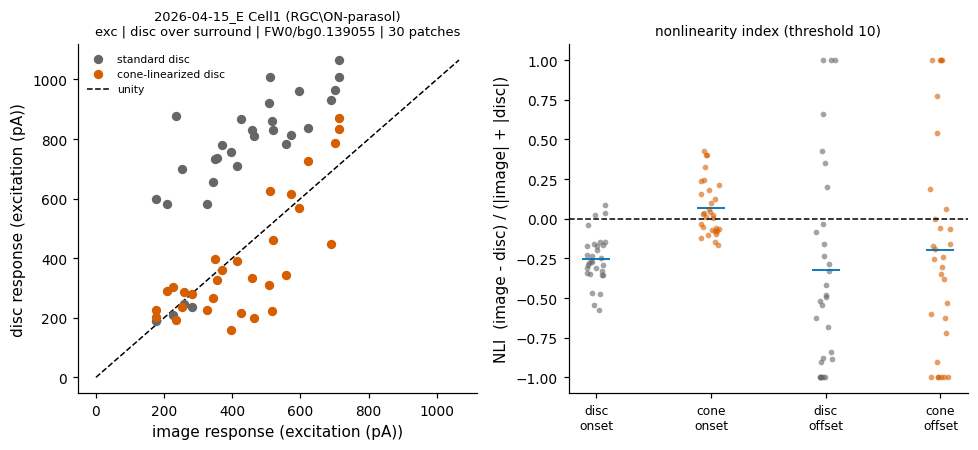

In [5]:
row = groups.sort_values('epochs', ascending=False).iloc[2]

# Before analyzing a single recording, see what else this cell has: the other
# conditions it was recorded in, and whether the one picked is representative.
led.describe_cell(f'{row.exp_name}/{row.cell_label}', groups)

rec = led.analyze_group(row.exp_name, [int(b) for b in row.block_ids.split(',')],
                        online_analysis=row.onlineAnalysis)
led.plot_group(rec);

## 4. Batch analyze and save

Records go to `<OUTPUT_DIR>/linear_equivalent_disc/records.h5` with a `summary.csv` index,
upserted per (experiment, cell, mode, site, filter wheel, background) — same layout as the other
protocols, in its own directory. `skip_existing` makes re-running the notebook cheap.

In [ ]:
records = led.analyze_all(groups, save=True, plot=False, skip_existing=True)

## 5. Population: does cone linearization remove the nonlinearity?

Section 1 of `populationLinConeDisc.m`: one line per recording joining its mean standard-disc
NLI to its mean cone-linearized NLI, per recording mode, with a paired Wilcoxon signed-rank
test. If cone linearization captures what the cell is doing, the cone-linearized NLI should sit
closer to zero.

In [ ]:
summary = led.load_summary()
print(f'{len(summary)} stored recordings')
led.plot_population_nli(summary, window='onset');

In [ ]:
led.plot_population_nli(summary, window='offset');

### Pooled per-patch distributions

Section 2 of the population script — every patch from every recording, no per-cell averaging,
with a two-sample KS test.

In [ ]:
led.plot_nli_distributions(window='onset');

### Split by disc site

The annulus protocol puts the disc over the surround; the other two put it over the centre.
Those are different experiments and are worth looking at separately.

In [ ]:
for site in sorted(summary['site'].unique()):
    sub = summary[summary['site'].eq(site)]
    print(f'--- disc over {site}: {len(sub)} recordings ---')
    display(sub.groupby('online_analysis')[['nli_disc_onset', 'nli_cone_onset',
                                            'nli_disc_offset', 'nli_cone_offset']]
               .agg(['count', 'mean']).round(3))

## 6. Come back later

`load_summary()` reads the scalar index with no DataJoint or SSD access; `load_records()` pulls
the per-patch arrays.

In [ ]:
sc.scroll_table(summary[['exp_name', 'cell_label', 'cell_type', 'online_analysis',
                         'site', 'light_setting', 'n_patches',
                         'nli_disc_onset', 'nli_cone_onset']], height=320)

## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-04-03_E/Cell4'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [ ]:
led.list_cells(groups)

In [ ]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-04-03_E/Cell4'

cell_records = led.inspect_cell(CELL, groups)